# Imports and Cleaning the Data

Make sure to download the diabetes dataset and the IDS mapping csv into this notebook before running. Also once the cleaned dataset is saved make sure to download it so you have it for the other notebooks.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Uploading the dataset
# Make sure you have uploaded the diabetic_data csv to Google Colab before running
df = pd.read_csv("diabetic_data.csv")
df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [ ]:
# Checking the size of the dataset
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

df.columns

# Data types and if there are any missing values
df.info()
df.isnull().sum()

df["readmitted"].value_counts()
df["readmitted"].value_counts(normalize=True)


Number of rows: 101766
Number of columns: 50
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures

,proportion
readmitted,
NO,0.539119
>30,0.349282
<30,0.111599


In [ ]:
# Looking for missing values
missing_question = (df == "?").sum()
display(missing_question[missing_question > 0].sort_values(ascending=False))

df = df.replace("?", np.nan)

display(df.isnull().sum().sort_values(ascending=False).head(15))

,0
weight,98569
medical_specialty,49949
payer_code,40256
race,2273
diag_3,1423
diag_2,358
diag_1,21


,0
weight,98569
max_glu_serum,96420
A1Cresult,84748
medical_specialty,49949
payer_code,40256
race,2273
diag_3,1423
diag_2,358
diag_1,21
patient_nbr,0


In [ ]:
# Dropping weight since almost all of the values are missing
df = df.drop(columns=["weight"])

# Dropping payer code since a lot of the values are missing and it is not needed for prediction
df = df.drop(columns=["payer_code"])

# Keeping the missing lab results as their own category
df["max_glu_serum"] = df["max_glu_serum"].fillna("Not Recorded")
df["A1Cresult"] = df["A1Cresult"].fillna("Not Recorded")

# Filling in the other missing categorical values
df["medical_specialty"] = df["medical_specialty"].fillna("Unknown")
df["race"] = df["race"].fillna("Unknown")

# Filling in the missing diagnosis values
df["diag_1"] = df["diag_1"].fillna("Unknown")
df["diag_2"] = df["diag_2"].fillna("Unknown")
df["diag_3"] = df["diag_3"].fillna("Unknown")

# Checking that there are no missing values left
df.isnull().sum().sort_values(ascending=False).head(10)

,0
encounter_id,0
patient_nbr,0
race,0
gender,0
age,0
admission_type_id,0
discharge_disposition_id,0
admission_source_id,0
time_in_hospital,0
medical_specialty,0


In [ ]:
# Looking for duplicates
df.duplicated().sum()

np.int64(0)

In [ ]:
# Found that there were no duplicates
# Looking for unique values
df.nunique().sort_values()

,0
examide,1
citoglipton,1
acetohexamide,2
tolbutamide,2
diabetesMed,2
troglitazone,2
metformin-rosiglitazone,2
metformin-pioglitazone,2
glipizide-metformin,2
glimepiride-pioglitazone,2


In [ ]:
# Decided to drop examide and citoglipton since they only have one value and won't be useful in predicting readmission
df = df.drop(columns=["examide", "citoglipton"])
# Decided to drop these ID columns since they are only used to identify the patient and shouldn't be used for prediction
df = df.drop(columns=["encounter_id", "patient_nbr"])

In [ ]:
# Checking the updated size of the dataset
df.shape

(101766, 44)

In [ ]:
# Creating a binary target for the 30-day readmission
# 1 means the patient was readmitted within 30 days and 0 means they were not
df["readmitted_30"] = np.where(df["readmitted"] == "<30", 1, 0)

# Checking the number of patients in each group
df["readmitted_30"].value_counts()

,count
readmitted_30,
0,90409
1,11357


In [ ]:
# Checking the percentage of patients in each group
df["readmitted_30"].value_counts(normalize=True)

,proportion
readmitted_30,
0,0.888401
1,0.111599


In [ ]:
# Decided to drop the original readmitted column since it was used to create our target
# If it was kept then it would give the model information about the actual outcome
df = df.drop(columns=["readmitted"])

In [ ]:
# Looking at the discharge disposition codes before deciding which patients to remove
df["discharge_disposition_id"].value_counts().sort_index()

,count
discharge_disposition_id,
1,60234
2,2128
3,13954
4,815
5,1184
6,12902
7,623
8,108
9,21


In [ ]:
# Uploading the ID mapping file so we can understand what the codes mean
# Make sure you have uploaded it to Google Colab before running
ids = pd.read_csv("IDS_mapping.csv")

ids.head(30)

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NaN
6,7,Trauma Center
7,8,Not Mapped
8,NaN,NaN
9,discharge_disposition_id,description


In [ ]:
# Removing the patients who died or were discharged to hospice since they wouldn't be targeted for readmission interventions
exclude_discharge = [8, 11, 13, 14, 19, 20]

df = df[~df["discharge_disposition_id"].isin(exclude_discharge)].copy()

# Checking the updated size of the dataset
df.shape

(99235, 44)

In [ ]:
# Looking at the most common primary diagnosis codes
df["diag_1"].value_counts().head(15)

,count
diag_1,
428,6657
414,6550
786,4014
410,3444
486,3383
427,2720
491,2239
715,2147
682,2016


In [ ]:
# Looking at examples of the diagnosis codes
df[["diag_1", "diag_2", "diag_3"]].head(10)

,diag_1,diag_2,diag_3
0,250.83,Unknown,Unknown
1,276,250.01,255
2,648,250,V27
3,8,250.43,403
4,197,157,250
5,414,411,250
6,414,411,V45
7,428,492,250
8,398,427,38
9,434,198,486


In [ ]:
# Grouping the diagnosis codes into broader categories
def group_diagnosis(code):

    if code == "Unknown":
        return "Unknown"

    # V and E codes do not fall into the main numeric diagnosis groups
    if str(code).startswith(("V", "E")):
        return "Other"

    try:
        code = float(code)
    except:
        return "Other"

    if 390 <= code <= 459 or code == 785:
        return "Circulatory"
    elif 460 <= code <= 519 or code == 786:
        return "Respiratory"
    elif 520 <= code <= 579 or code == 787:
        return "Digestive"
    elif 250 <= code < 251:
        return "Diabetes"
    elif 800 <= code <= 999:
        return "Injury"
    elif 710 <= code <= 739:
        return "Musculoskeletal"
    elif 580 <= code <= 629 or code == 788:
        return "Genitourinary"
    elif 140 <= code <= 239:
        return "Neoplasms"
    else:
        return "Other"

In [ ]:
# Creating grouped diagnosis variables
df["diag_1_group"] = df["diag_1"].apply(group_diagnosis)
df["diag_2_group"] = df["diag_2"].apply(group_diagnosis)
df["diag_3_group"] = df["diag_3"].apply(group_diagnosis)

In [ ]:
# Checking the new primary diagnosis groups
df["diag_1_group"].value_counts()

,count
diag_1_group,
Circulatory,29664
Other,17758
Respiratory,13929
Digestive,9328
Diabetes,8643
Injury,6833
Genitourinary,5001
Musculoskeletal,4929
Neoplasms,3130


In [ ]:
# Checking the diagnosis groups we created
print("Primary diagnosis:")
print(df["diag_1_group"].value_counts())

print("\nSecondary diagnosis:")
print(df["diag_2_group"].value_counts())

print("\nAdditional diagnosis:")
print(df["diag_3_group"].value_counts())

Primary diagnosis:
diag_1_group
Circulatory        29664
Other              17758
Respiratory        13929
Digestive           9328
Diabetes            8643
Injury              6833
Genitourinary       5001
Musculoskeletal     4929
Neoplasms           3130
Unknown               20
Name: count, dtype: int64

Secondary diagnosis:
diag_2_group
Circulatory        31137
Other              25986
Diabetes           12690
Respiratory        10385
Genitourinary       8145
Digestive           4085
Injury              2373
Neoplasms           2326
Musculoskeletal     1752
Unknown              356
Name: count, dtype: int64

Additional diagnosis:
diag_3_group
Circulatory        29582
Other              28550
Diabetes           16952
Respiratory         7000
Genitourinary       6432
Digestive           3856
Musculoskeletal     1892
Injury              1892
Neoplasms           1661
Unknown             1418
Name: count, dtype: int64


In [ ]:
# Dropping the original diagnosis codes since we created broader diagnosis groups
# This keeps the diagnosis information without having hundreds of different categories
df = df.drop(columns=["diag_1", "diag_2", "diag_3"])

# Checking the updated size of the dataset
df.shape

(99235, 44)

In [ ]:
# Checking the remaining variables and how many different values each one has
for column in df.columns:
    print(column, "-", df[column].dtype, "-", df[column].nunique())

race - object - 6
gender - object - 3
age - object - 10
admission_type_id - int64 - 8
discharge_disposition_id - int64 - 20
admission_source_id - int64 - 17
time_in_hospital - int64 - 14
medical_specialty - object - 73
num_lab_procedures - int64 - 118
num_procedures - int64 - 7
num_medications - int64 - 75
number_outpatient - int64 - 39
number_emergency - int64 - 33
number_inpatient - int64 - 21
number_diagnoses - int64 - 16
max_glu_serum - object - 4
A1Cresult - object - 4
metformin - object - 4
repaglinide - object - 4
nateglinide - object - 4
chlorpropamide - object - 4
glimepiride - object - 4
acetohexamide - object - 2
glipizide - object - 4
glyburide - object - 4
tolbutamide - object - 2
pioglitazone - object - 4
rosiglitazone - object - 4
acarbose - object - 4
miglitol - object - 4
troglitazone - object - 2
tolazamide - object - 3
insulin - object - 4
glyburide-metformin - object - 4
glipizide-metformin - object - 2
glimepiride-pioglitazone - object - 2
metformin-rosiglitazone -

In [ ]:
# Looking at the most common medical specialties
df["medical_specialty"].value_counts().head(20)

,count
medical_specialty,
Unknown,48550
InternalMedicine,14232
Emergency/Trauma,7417
Family/GeneralPractice,7240
Cardiology,5278
Surgery-General,3055
Nephrology,1538
Orthopedics,1387
Orthopedics-Reconstructive,1227


In [ ]:
# Checking how many specialties have fewer than 500 patients
(df["medical_specialty"].value_counts() < 500).sum()

np.int64(56)

In [ ]:
# Looking at the least common medical specialties before deciding if they should be grouped
df["medical_specialty"].value_counts().tail(30)

,count
medical_specialty,
Obstetrics,19
Anesthesiology-Pediatric,19
Rheumatology,17
Pathology,16
OutreachServices,12
Anesthesiology,12
Surgery-Colon&Rectal,11
Pediatrics-Neurology,10
PhysicianNotFound,10


In [ ]:
# Comparing different cutoffs for grouping rare medical specialties
specialty_counts = df["medical_specialty"].value_counts()

for cutoff in [50, 100, 250, 500]:
    rare_categories = (specialty_counts < cutoff).sum()
    rare_patients = specialty_counts[specialty_counts < cutoff].sum()

    print(
        "Cutoff:", cutoff,
        "| Specialties grouped:", rare_categories,
        "| Patients affected:", rare_patients
    )

Cutoff: 50 | Specialties grouped: 38 | Patients affected: 482
Cutoff: 100 | Specialties grouped: 44 | Patients affected: 910
Cutoff: 250 | Specialties grouped: 52 | Patients affected: 2009
Cutoff: 500 | Specialties grouped: 56 | Patients affected: 3431


In [ ]:
# Grouping medical specialties with fewer than 100 patients into Other
# This reduces very small categories while keeping almost all of the original specialty information
specialty_counts = df["medical_specialty"].value_counts()

rare_specialties = specialty_counts[specialty_counts < 100].index

df["medical_specialty"] = df["medical_specialty"].replace(
    rare_specialties,
    "Other"
)

# Checking the updated specialty groups
df["medical_specialty"].value_counts()

,count
medical_specialty,
Unknown,48550
InternalMedicine,14232
Emergency/Trauma,7417
Family/GeneralPractice,7240
Cardiology,5278
Surgery-General,3055
Nephrology,1538
Orthopedics,1387
Orthopedics-Reconstructive,1227


In [ ]:
# Saving the cleaned dataset so I can use it in the LLM notebook
df.to_csv("cleaned_diabetes_data.csv", index=False)

# Exploratory Data Analysis

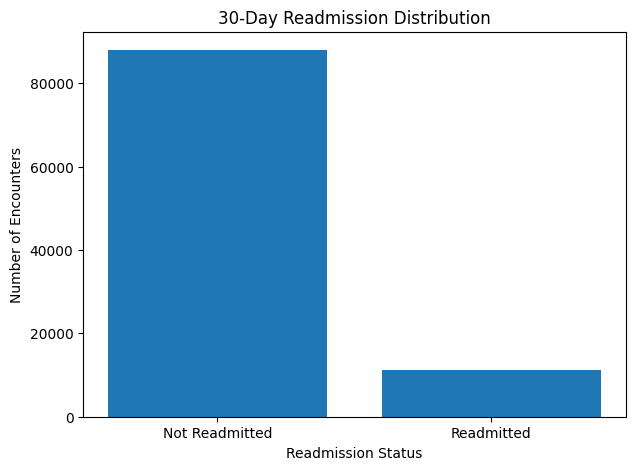

In [ ]:
# Looking at the number of patients who were and were not readmitted within 30 days
readmission_counts = df["readmitted_30"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(["Not Readmitted", "Readmitted"], readmission_counts.values)

plt.title("30-Day Readmission Distribution")
plt.xlabel("Readmission Status")
plt.ylabel("Number of Encounters")

plt.show()

In [ ]:
# Calculating the 30-day readmission rate
readmission_rate = df["readmitted_30"].mean() * 100

print("30-day readmission rate:", round(readmission_rate, 2), "%")

30-day readmission rate: 11.39 %


In this graph we can see that only about 11% of the encounters resulted in a readmission within 30 days, showing that the target is imbalanced. This will be important to consider when we start training and evaluating the models.

In [ ]:
# Calculating the 30-day readmission rate for each age group
age_readmission = (
    df.groupby("age", observed=False)["readmitted_30"]
    .mean()
    .mul(100)
    .reset_index()
)

age_readmission

,age,readmitted_30
0,[0-10),1.875000
1,[10-20),5.797101
2,[20-30),14.329083
3,[30-40),11.282597
4,[40-50),10.671400
5,[50-60),9.753376
6,[60-70),11.292591
7,[70-80),12.053571
8,[80-90),12.567707
9,[90-100),11.896485


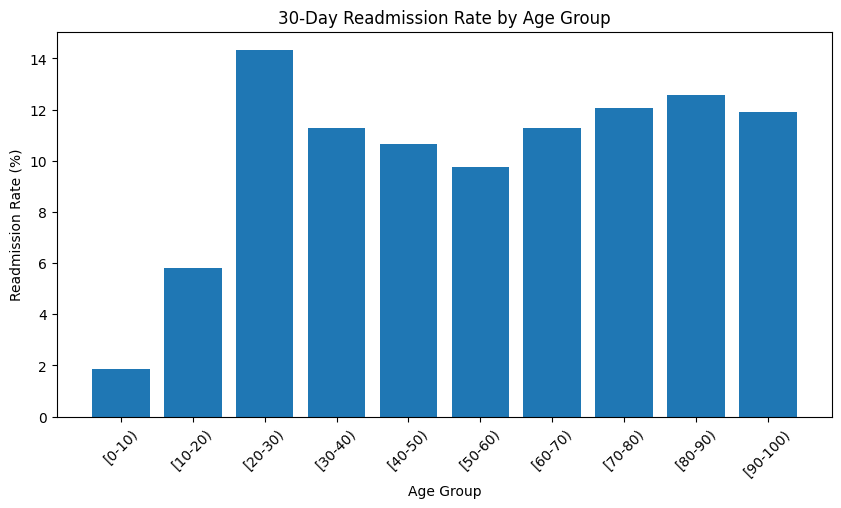

In [ ]:
# Looking at how 30-day readmission rates change across age groups
plt.figure(figsize=(10, 5))
plt.bar(age_readmission["age"], age_readmission["readmitted_30"])

plt.title("30-Day Readmission Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Readmission Rate (%)")

plt.xticks(rotation=45)
plt.show()

In the graph we can see that readmission rates vary across the different age groups, but there isn't a clear pattern showing that readmission risk consistently increases with age.

In [ ]:
# Comparing previous inpatient visits for patients who were and were not readmitted
df.groupby("readmitted_30")["number_inpatient"].mean()

,number_inpatient
readmitted_30,
0,0.554676
1,1.222763


In [ ]:
# Calculating readmission rates based on the number of previous inpatient visits
inpatient_readmission = (
    df.groupby("number_inpatient")["readmitted_30"]
    .mean()
    .mul(100)
    .reset_index()
)

inpatient_readmission

,number_inpatient,readmitted_30
0,0,8.587576
1,1,13.252123
2,2,17.918837
3,3,21.034905
4,4,24.107143
5,5,32.025316
6,6,34.810127
7,7,36.259542
8,8,46.206897
9,9,43.119266


In [ ]:
# Grouping previous inpatient visits so the small higher groups don't make the readmission rates look misleading
df["inpatient_group"] = pd.cut(
    df["number_inpatient"],
    bins=[-1, 0, 1, 2, 3, 4, float("inf")],
    labels=["0", "1", "2", "3", "4", "5+"]
)

# Looking at the number of encounters and readmission rate for each group
inpatient_grouped = (
    df.groupby("inpatient_group", observed=False)["readmitted_30"]
    .agg(["count", "mean"])
    .reset_index()
)

inpatient_grouped["readmission_rate"] = inpatient_grouped["mean"] * 100

inpatient_grouped

,inpatient_group,count,mean,readmission_rate
0,0,66177,0.085876,8.587576
1,1,18963,0.132521,13.252123
2,2,7294,0.179188,17.918837
3,3,3266,0.210349,21.034905
4,4,1568,0.241071,24.107143
5,5+,1967,0.371632,37.163193


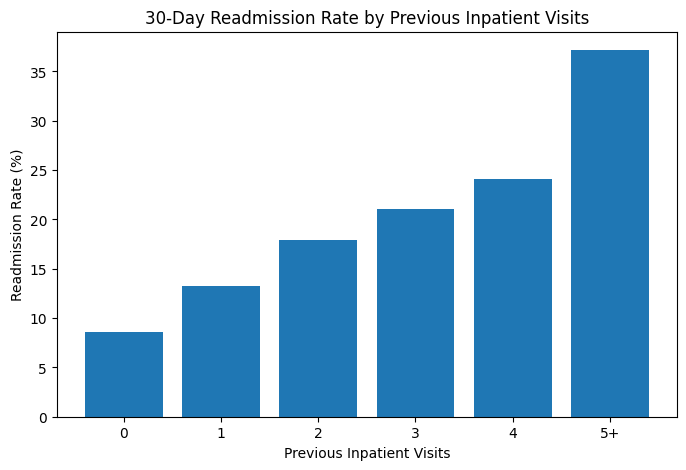

In [ ]:
# Looking at how 30-day readmission rates change with previous inpatient visits
plt.figure(figsize=(8, 5))

plt.bar(
    inpatient_grouped["inpatient_group"].astype(str),
    inpatient_grouped["readmission_rate"]
)

plt.title("30-Day Readmission Rate by Previous Inpatient Visits")
plt.xlabel("Previous Inpatient Visits")
plt.ylabel("Readmission Rate (%)")

plt.show()

In this graph we can see that previous inpatient visits show a strong relationship with 30-day readmission. The readmission rate increases from about 8.6% for patients with no previous inpatient visits to about 37.2% for patients with 5 or more.

In [ ]:
# Removing the grouped variable since it was only created for the EDA
df = df.drop(columns=["inpatient_group"])

In [ ]:
# Looking at readmission rates based on the number of previous emergency visits
emergency_readmission = (
    df.groupby("number_emergency")["readmitted_30"]
    .agg(["count", "mean"])
    .reset_index()
)

emergency_readmission["readmission_rate"] = (
    emergency_readmission["mean"] * 100
)

emergency_readmission

,number_emergency,count,mean,readmission_rate
0,0,88144,0.106837,10.683654
1,1,7472,0.146681,14.668094
2,2,1983,0.187595,18.759455
3,3,706,0.208215,20.821530
4,4,369,0.308943,30.894309
5,5,190,0.247368,24.736842
6,6,93,0.236559,23.655914
7,7,72,0.263889,26.388889
8,8,50,0.320000,32.000000
9,9,33,0.363636,36.363636


In [ ]:
# Grouping previous emergency visits so the small higher groups don't make the readmission rates look misleading
df["emergency_group"] = pd.cut(
    df["number_emergency"],
    bins=[-1, 0, 1, 2, 3, float("inf")],
    labels=["0", "1", "2", "3", "4+"]
)

# Looking at the number of encounters and readmission rate for each group
emergency_grouped = (
    df.groupby("emergency_group", observed=False)["readmitted_30"]
    .agg(["count", "mean"])
    .reset_index()
)

emergency_grouped["readmission_rate"] = emergency_grouped["mean"] * 100

emergency_grouped

,emergency_group,count,mean,readmission_rate
0,0,88144,0.106837,10.683654
1,1,7472,0.146681,14.668094
2,2,1983,0.187595,18.759455
3,3,706,0.208215,20.821530
4,4+,930,0.287097,28.709677


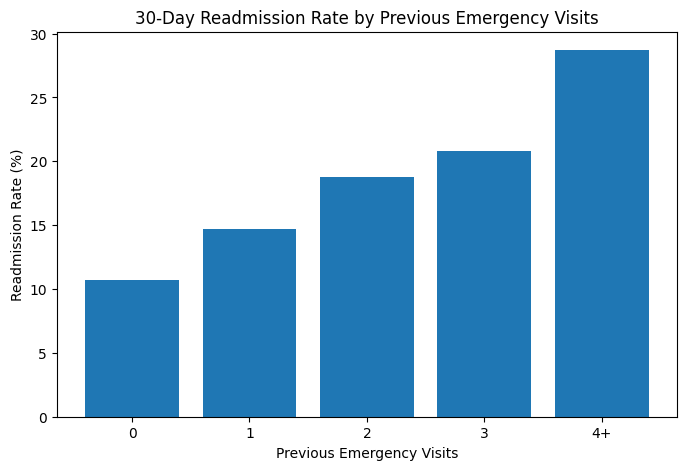

In [ ]:
# Looking at how 30-day readmission rates change with previous emergency visits
plt.figure(figsize=(8, 5))

plt.bar(
    emergency_grouped["emergency_group"].astype(str),
    emergency_grouped["readmission_rate"]
)

plt.title("30-Day Readmission Rate by Previous Emergency Visits")
plt.xlabel("Previous Emergency Visits")
plt.ylabel("Readmission Rate (%)")

plt.show()

In this graph we can see that a similar pattern was seen with previous emergency visits, like the previous inpatient visits. The readmission rate increases from about 10.7% for patients with no previous emergency visits to about 28.7% for patients with 4 or more.

In [ ]:
# Removing the grouped variable since it was only created for the EDA
df = df.drop(columns=["emergency_group"])

In [ ]:
# Looking at the relationship between number of diagnoses and 30-day readmission
diagnosis_readmission = (
    df.groupby("number_diagnoses")["readmitted_30"]
    .agg(["count", "mean"])
    .reset_index()
)

diagnosis_readmission["readmission_rate"] = (
    diagnosis_readmission["mean"] * 100
)

diagnosis_readmission

,number_diagnoses,count,mean,readmission_rate
0,1,219,0.059361,5.936073
1,2,1020,0.060784,6.078431
2,3,2823,0.074035,7.403471
3,4,5492,0.083212,8.321194
4,5,11286,0.092150,9.214957
5,6,9977,0.105142,10.514183
6,7,10201,0.109009,10.900892
7,8,10345,0.120638,12.063799
8,9,47763,0.127546,12.754643
9,10,16,0.187500,18.750000


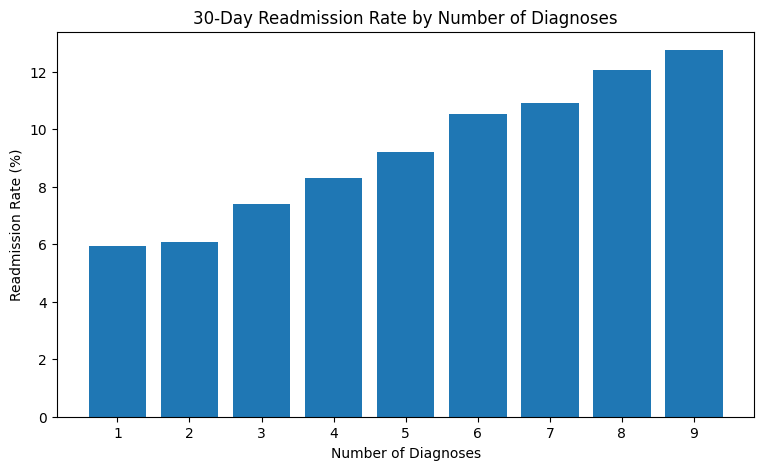

In [ ]:
# Decided to keep the diagnosis counts with enough encounters for a meaningful comparison
diagnosis_plot = diagnosis_readmission[
    diagnosis_readmission["number_diagnoses"] <= 9
]

# Looking at how 30-day readmission rates change with the number of diagnoses
plt.figure(figsize=(9, 5))

plt.bar(
    diagnosis_plot["number_diagnoses"],
    diagnosis_plot["readmission_rate"]
)

plt.title("30-Day Readmission Rate by Number of Diagnoses")
plt.xlabel("Number of Diagnoses")
plt.ylabel("Readmission Rate (%)")

plt.xticks(diagnosis_plot["number_diagnoses"])
plt.show()

In this graph we can see that readmission rates generally increase as the number of diagnoses increase. This suggests that patients with more complex health conditions may have a higher risk of being readmitted.

In [ ]:
# Looking at the relationship between length of stay and 30-day readmission
hospital_stay = (
    df.groupby("time_in_hospital")["readmitted_30"]
    .agg(["count", "mean"])
    .reset_index()
)

# Changing the mean into a percentage so it is easier to interpret
hospital_stay["readmission_rate"] = hospital_stay["mean"] * 100

hospital_stay

,time_in_hospital,count,mean,readmission_rate
0,1,13822,0.083924,8.392418
1,2,16887,0.100906,10.090602
2,3,17420,0.108037,10.803674
3,4,13668,0.119769,11.976880
4,5,9734,0.122766,12.276556
5,6,7347,0.128624,12.862393
6,7,5686,0.131199,13.119944
7,8,4264,0.145872,14.587242
8,9,2873,0.142360,14.235990
9,10,2253,0.148691,14.869063


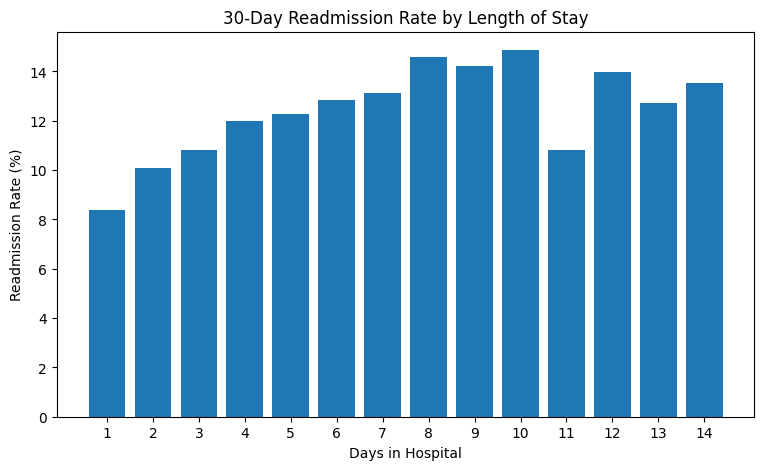

In [ ]:
# Looking at how 30-day readmission rates change with length of stay
plt.figure(figsize=(9, 5))

plt.bar(
    hospital_stay["time_in_hospital"],
    hospital_stay["readmission_rate"]
)

plt.title("30-Day Readmission Rate by Length of Stay")
plt.xlabel("Days in Hospital")
plt.ylabel("Readmission Rate (%)")

plt.xticks(hospital_stay["time_in_hospital"])
plt.show()

In this graph we can see that longer hospital stays generally have higher readmission rates. We can especially see this from 1 to 10 days. Although, the pattern is not completely consistent. We can see more inconsistencies after day 10 and there are some small inconsistencies before day 10 as well.

In [ ]:
# Looking at the relationship between number of medications and 30-day readmission
medication_readmission = (
    df.groupby("num_medications")["readmitted_30"]
    .agg(["count", "mean"])
    .reset_index()
)

# Changing the mean into a percentage so it is easier to interpret
medication_readmission["readmission_rate"] = (
    medication_readmission["mean"] * 100
)

medication_readmission

,num_medications,count,mean,readmission_rate
0,1,260,0.042308,4.230769
1,2,457,0.085339,8.533917
2,3,874,0.074371,7.437071
3,4,1383,0.081706,8.170644
4,5,1964,0.075356,7.535642
...,...,...,...,...
70,72,3,1.000000,100.000000
71,74,1,0.000000,0.000000
72,75,2,0.000000,0.000000
73,79,1,0.000000,0.000000


In [ ]:
# Grouping the number of medications so the readmission rates are easier to compare
df["medication_group"] = pd.cut(
    df["num_medications"],
    bins=[0, 5, 10, 15, 20, 30, float("inf")],
    labels=["1-5", "6-10", "11-15", "16-20", "21-30", "31+"],
    include_lowest=True
)

# Looking at the number of encounters and readmission rate for each group
medication_grouped = (
    df.groupby("medication_group", observed=False)["readmitted_30"]
    .agg(["count", "mean"])
    .reset_index()
)

# Changing the mean into a percentage so it is easier to interpret
medication_grouped["readmission_rate"] = (
    medication_grouped["mean"] * 100
)

medication_grouped

,medication_group,count,mean,readmission_rate
0,1-5,4938,0.076144,7.614419
1,6-10,20360,0.095972,9.597250
2,11-15,28818,0.110799,11.079881
3,16-20,22073,0.124134,12.413356
4,21-30,18041,0.132310,13.230974
5,31+,5005,0.129670,12.967033


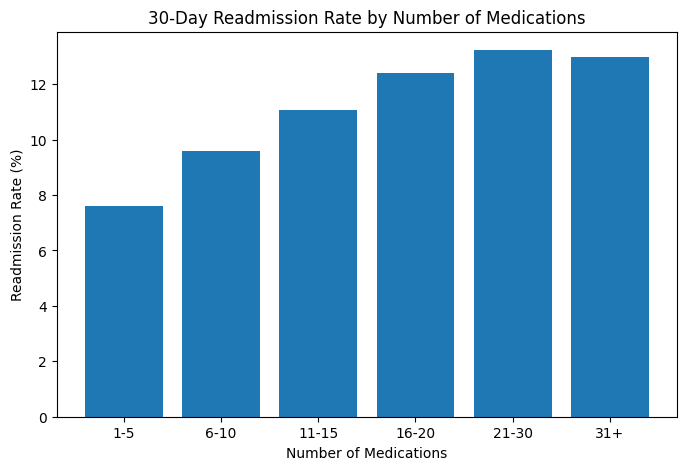

In [ ]:
# Looking at how 30-day readmission rates change with the number of medications
plt.figure(figsize=(8, 5))

plt.bar(
    medication_grouped["medication_group"].astype(str),
    medication_grouped["readmission_rate"]
)

plt.title("30-Day Readmission Rate by Number of Medications")
plt.xlabel("Number of Medications")
plt.ylabel("Readmission Rate (%)")

plt.show()

In this graph we can see that readmission rates generally increase as the number of medications increase. This suggests that patients with more medications may have more complex care needs that may be important when identifying higher-risk patients.

In [ ]:
# Removing the grouped variable since it was only created for the EDA
df = df.drop(columns=["medication_group"])

In [ ]:
# Looking at 30-day readmission rates across primary diagnosis groups
diagnosis_group_readmission = (
    df.groupby("diag_1_group")["readmitted_30"]
    .agg(["count", "mean"])
    .reset_index()
)

# Changing the mean into a percentage so it is easier to interpret
diagnosis_group_readmission["readmission_rate"] = (
    diagnosis_group_readmission["mean"] * 100
)

# Sorting from highest to lowest readmission rate
diagnosis_group_readmission = diagnosis_group_readmission.sort_values(
    "readmission_rate",
    ascending=False
)

diagnosis_group_readmission

,diag_1_group,count,mean,readmission_rate
9,Unknown,20,0.250000,25.000000
1,Diabetes,8643,0.130973,13.097304
4,Injury,6833,0.123957,12.395727
7,Other,17758,0.116905,11.690506
0,Circulatory,29664,0.116842,11.684196
3,Genitourinary,5001,0.110378,11.037792
6,Neoplasms,3130,0.108946,10.894569
2,Digestive,9328,0.108169,10.816895
8,Respiratory,13929,0.100582,10.058152
5,Musculoskeletal,4929,0.095354,9.535403


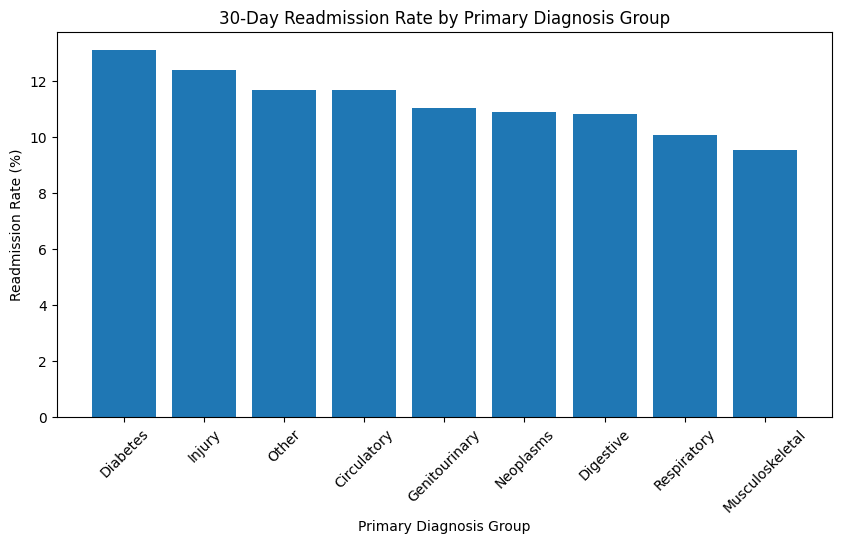

In [ ]:
# Removing the very small Unknown group from the EDA graph
diagnosis_plot = diagnosis_group_readmission[
    diagnosis_group_readmission["diag_1_group"] != "Unknown"
]

# Comparing 30-day readmission rates across primary diagnosis groups
plt.figure(figsize=(10, 5))

plt.bar(
    diagnosis_plot["diag_1_group"],
    diagnosis_plot["readmission_rate"]
)

plt.title("30-Day Readmission Rate by Primary Diagnosis Group")
plt.xlabel("Primary Diagnosis Group")
plt.ylabel("Readmission Rate (%)")

plt.xticks(rotation=45)
plt.show()

In this graph we can see that readmission rates vary somewhat across the primary diagnosis groups, with diabetes having the highest rate among the main diagnosis groups. Although, the differences across the groups were small.

In [ ]:
# Looking at 30-day readmission rates across A1C result groups
a1c_readmission = (
    df.groupby("A1Cresult")["readmitted_30"]
    .agg(["count", "mean"])
    .reset_index()
)

# Changing the mean into a percentage so it is easier to interpret
a1c_readmission["readmission_rate"] = (
    a1c_readmission["mean"] * 100
)

a1c_readmission

,A1Cresult,count,mean,readmission_rate
0,>7,3767,0.101407,10.140696
1,>8,8128,0.099532,9.953248
2,Norm,4918,0.097397,9.739732
3,Not Recorded,82422,0.116826,11.682560


I also decided to look at the A1C results and it shows us that there is relatively small differences in 30-day readmission rates. Most of the encounters also didn't have an A1C result recorded. Overall, I think that this variable may have limited usefulness on its own for identifying high-risk patients.

## Summary for the EDA
This analysis shows us that previous hospital use had the strongest relationship with 30-day readmission, especially the number of previous inpatient and emergency visits. We also saw that the number of diagnoses and medications showed that patients with more complex healthcare needs tended to have higher readmission rates. Overall, these findings can help identify which patients may be at a higher risk of readmission and could benefit the most from additional support after discharge.

In [ ]:
# Checking the final dataset before modeling
df.shape

(99235, 44)

# Model Development

To make the final model more practical for deployment, a reduced predictor set is used for all structured models. The predictors were chosen based on the EDA, model importance patterns, clinical/business relevance, and whether they would be reasonable to collect in a user-facing decision-support tool.

Using the same reduced predictor set for Logistic Regression, Random Forest, and XGBoost keeps the model comparison fair.


## Reduced Predictor Set


In [ ]:
# Selecting the predictors to use in the final models
selected_features = [
    "age",
    "admission_type_id",
    "discharge_disposition_id",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses",
    "A1Cresult",
    "diabetesMed",
    "diag_1_group",
    "diag_2_group",
    "diag_3_group",
]

# Checking that all selected predictors are in the cleaned dataset
missing_selected = [
    col for col in selected_features
    if col not in df.columns
]

# Stopping the code if any selected predictors are missing
if missing_selected:
    raise KeyError(
        f"Missing reduced predictors: {missing_selected}"
    )

# Creating the predictor and target datasets
X = df[selected_features].copy()
y = df["readmitted_30"].astype(int)

# Checking the final predictor set
print("Predictor count:", len(selected_features))
print("Predictors:", selected_features)
print("Predictor matrix:", X.shape)
print("Target:", y.shape)

Predictor count: 16
Predictors: ['age', 'admission_type_id', 'discharge_disposition_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'A1Cresult', 'diabetesMed', 'diag_1_group', 'diag_2_group', 'diag_3_group']
Predictor matrix: (99235, 16)
Target: (99235,)


## Train/Test Split


In [ ]:
from sklearn.model_selection import train_test_split

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Checking the size of each dataset
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

# Checking that the readmission rate stayed similar between the training and testing sets
print(
    "Training readmission rate:",
    round(y_train.mean() * 100, 2),
    "%"
)

print(
    "Testing readmission rate:",
    round(y_test.mean() * 100, 2),
    "%"
)

Training set: (79388, 16)
Testing set: (19847, 16)
Training readmission rate: 11.39 %
Testing readmission rate: 11.39 %


## Data Preprocessing


In [ ]:
# The three ID fields are category codes rather than continuous measurements.
id_columns = [
    "admission_type_id",
    "discharge_disposition_id",
]

numeric_columns = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_columns = [
    col for col in numeric_columns
    if col not in id_columns
]

categorical_columns = categorical_columns + [
    col for col in id_columns
    if col not in categorical_columns
]

print("Numeric predictors:")
print(numeric_columns)

print("\nCategorical predictors:")
print(categorical_columns)


Numeric predictors:
['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

Categorical predictors:
['age', 'A1Cresult', 'diabetesMed', 'diag_1_group', 'diag_2_group', 'diag_3_group', 'admission_type_id', 'discharge_disposition_id']


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

# Standardizing the numeric predictors
numeric_transformer = StandardScaler()

# One-hot encoding the categorical predictors
categorical_transformer = OneHotEncoder(
    handle_unknown="ignore",
    drop="first"
)

# Applying preprocessing to the numeric and categorical predictors
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['time_in_hospital', 'num_lab_procedures',
                                  'num_procedures', 'num_medications',
                                  'number_outpatient', 'number_emergency',
                                  'number_inpatient', 'number_diagnoses']),
                                ('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['age', 'A1Cresult', 'diabetesMed',
                                  'diag_1_group', 'diag_2_group',
                                  'diag_3_group', 'admission_type_id',
                                  'discharge_disposition_id'])])

## Logistic Regression




In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", logistic_model)
    ]
)

logistic_pipeline.fit(
    X_train,
    y_train
)

logistic_probabilities = logistic_pipeline.predict_proba(
    X_test
)[:, 1]


## Random Forest




In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", random_forest_model)
    ]
)

random_forest_pipeline.fit(
    X_train,
    y_train
)

rf_probabilities = random_forest_pipeline.predict_proba(
    X_test
)[:, 1]


## XGBoost Model



In [ ]:
from xgboost import XGBClassifier

negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())

scale_pos_weight = (
    negative_count / positive_count
)

print(
    "Scale positive weight:",
    round(scale_pos_weight, 2)
)

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", xgb_model)
    ]
)

xgb_pipeline.fit(
    X_train,
    y_train
)

xgb_probabilities = xgb_pipeline.predict_proba(
    X_test
)[:, 1]


Scale positive weight: 7.78


## Model Comparison at the 0.50 Starting Threshold


In [ ]:
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)

# Creating a function to calculate the evaluation metrics for each model at the selected threshold
def metric_row(
    model_name,
    probabilities,
    threshold=0.50
):

    # Converting predicted probabilities into readmission predictions
    predictions = (
        probabilities >= threshold
    ).astype(int)

    # Calculating the model performance metrics
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            probabilities
        ),
    }


# Comparing all three models using a 0.50 threshold
model_comparison = pd.DataFrame([
    metric_row(
        "Logistic Regression",
        logistic_probabilities
    ),
    metric_row(
        "Random Forest",
        rf_probabilities
    ),
    metric_row(
        "XGBoost",
        xgb_probabilities
    ),
])

# Displaying the model comparison
display(
    model_comparison.round(3)
)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.680,0.185,0.534,0.275,0.661
1,Random Forest,0.736,0.196,0.427,0.269,0.663
2,XGBoost,0.668,0.186,0.566,0.280,0.672


### ROC Curve Comparison


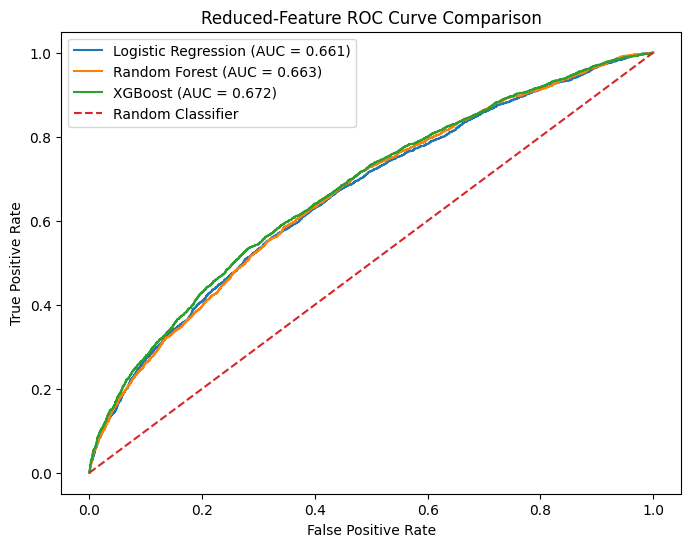

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

# Creating an ROC curve for each model
for model_name, probabilities in {
    "Logistic Regression": logistic_probabilities,
    "Random Forest": rf_probabilities,
    "XGBoost": xgb_probabilities,
}.items():

    # Calculating the false positive and true positive rates
    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    # Calculating ROC-AUC for the model
    auc_value = roc_auc_score(
        y_test,
        probabilities
    )

    # Adding the model ROC curve to the graph
    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {auc_value:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Reduced-Feature ROC Curve Comparison")
plt.legend()

plt.show()

## Threshold Analysis

The false negatives are important for this decision, which is why multiple thresholds are compared. We can see that the lower thresholds generally increase recall but also increase the number of patients who would receive additional care.


In [ ]:
# Setting the thresholds to compare
thresholds = [
    0.20,
    0.30,
    0.40,
    0.50,
    0.60,
]

# Storing the predicted probabilities for each model
model_probabilities = {
    "Logistic Regression": logistic_probabilities,
    "Random Forest": rf_probabilities,
    "XGBoost": xgb_probabilities,
}

# Creating an empty list to store the results
threshold_results = []

# Evaluating each model at each threshold
for model_name, probabilities in model_probabilities.items():

    for threshold in thresholds:

        # Converting probabilities into readmission predictions
        predictions = (
            probabilities >= threshold
        ).astype(int)

        # Getting the confusion matrix results
        tn, fp, fn, tp = confusion_matrix(
            y_test,
            predictions
        ).ravel()

        # Saving the performance results
        threshold_results.append({
            "Model": model_name,
            "Threshold": threshold,
            "Precision": precision_score(
                y_test,
                predictions,
                zero_division=0
            ),
            "Recall": recall_score(
                y_test,
                predictions,
                zero_division=0
            ),
            "F1-Score": f1_score(
                y_test,
                predictions,
                zero_division=0
            ),
            "Patients Flagged": int(
                predictions.sum()
            ),
            "Readmissions Caught": int(tp),
            "Readmissions Missed": int(fn)
        })

# Converting the threshold results into a dataframe
threshold_results = pd.DataFrame(
    threshold_results
)

display(
    threshold_results.round(3)
)

,Model,Threshold,Precision,Recall,F1-Score,Patients Flagged,Readmissions Caught,Readmissions Missed
0,Logistic Regression,0.2,0.114,1.000,0.205,19839,2260,0
1,Logistic Regression,0.3,0.117,0.988,0.210,19032,2234,26
2,Logistic Regression,0.4,0.140,0.803,0.239,12917,1814,446
3,Logistic Regression,0.5,0.185,0.534,0.275,6511,1207,1053
4,Logistic Regression,0.6,0.239,0.306,0.269,2893,692,1568
5,Random Forest,0.2,0.114,1.000,0.205,19806,2259,1
6,Random Forest,0.3,0.120,0.970,0.214,18203,2193,67
7,Random Forest,0.4,0.146,0.784,0.247,12096,1772,488
8,Random Forest,0.5,0.196,0.427,0.269,4915,965,1295
9,Random Forest,0.6,0.308,0.157,0.208,1151,355,1905


## Cost Analysis Assumptions
Since the dataset does not include actual hospital costs or the cost of providing additional post-discharge support, a few assumptions were made for the cost analysis. The cost per readmission is 16,300 dollars. I chose this cost because AHRQ reported it as the average cost of a hospital readmission in 2020. The cost per intervention is 200 dollars per patient. This is going to be used as a starting assumption for the cost of providing post-discharge support to a patient that is identified as higher risk. The intervention effectiveness is going to be 20%. This means that I will assume that the additonal support could prevent 20% of the readmissions out of the patients who are targeted for intervention. There is research that has shown that transitonal care intereventions can help reduce 30-day readmissions, but the effectiveness depends on the hospital and what kind of intervention it is. These assumptions help provide a starting point, so that we can compare the models and the thresholds.

Sources: https://www.ahrq.gov/data/infographics/hospital-readmission-costs.html?utm_source=chatgpt.com

https://www.ahrq.gov/data/infographics/hospital-readmission-costs.html?utm_source=chatgpt.com


In [ ]:
# Setting the assumptions for the cost analysis
cost_per_readmission = 16300
cost_per_intervention = 200
intervention_effectiveness = 0.20

cost_results = threshold_results.copy()

# Estimating the number of readmissions that could be prevented by the intervention
cost_results["Expected Readmissions Avoided"] = (
    cost_results["Readmissions Caught"]
    * intervention_effectiveness
)

# Estimating savings from avoided readmissions
cost_results["Estimated Savings"] = (
    cost_results["Expected Readmissions Avoided"]
    * cost_per_readmission
)

# Calculating the total cost of providing the intervention to flagged patients
cost_results["Intervention Cost"] = (
    cost_results["Patients Flagged"]
    * cost_per_intervention
)

# Calculating the estimated net value
cost_results["Net Value"] = (
    cost_results["Estimated Savings"]
    - cost_results["Intervention Cost"]
)

# Calculating the estimated return on investment
cost_results["ROI"] = (
    cost_results["Net Value"]
    / cost_results["Intervention Cost"]
) * 100

# Calculating how effective the intervention would need to be for the hospital to break even
cost_results["Break-Even Effectiveness"] = (
    cost_results["Intervention Cost"]
    /
    (
        cost_results["Readmissions Caught"]
        * cost_per_readmission
    )
) * 100

display(
    cost_results.round(2)
)


,Model,Threshold,Precision,Recall,F1-Score,Patients Flagged,Readmissions Caught,Readmissions Missed,Expected Readmissions Avoided,Estimated Savings,Intervention Cost,Net Value,ROI,Break-Even Effectiveness
0,Logistic Regression,0.2,0.11,1.00,0.20,19839,2260,0,452.0,7367600.0,3967800,3399800.0,85.68,10.77
1,Logistic Regression,0.3,0.12,0.99,0.21,19032,2234,26,446.8,7282840.0,3806400,3476440.0,91.33,10.45
2,Logistic Regression,0.4,0.14,0.80,0.24,12917,1814,446,362.8,5913640.0,2583400,3330240.0,128.91,8.74
3,Logistic Regression,0.5,0.19,0.53,0.28,6511,1207,1053,241.4,3934820.0,1302200,2632620.0,202.17,6.62
4,Logistic Regression,0.6,0.24,0.31,0.27,2893,692,1568,138.4,2255920.0,578600,1677320.0,289.89,5.13
5,Random Forest,0.2,0.11,1.00,0.20,19806,2259,1,451.8,7364340.0,3961200,3403140.0,85.91,10.76
6,Random Forest,0.3,0.12,0.97,0.21,18203,2193,67,438.6,7149180.0,3640600,3508580.0,96.37,10.18
7,Random Forest,0.4,0.15,0.78,0.25,12096,1772,488,354.4,5776720.0,2419200,3357520.0,138.79,8.38
8,Random Forest,0.5,0.20,0.43,0.27,4915,965,1295,193.0,3145900.0,983000,2162900.0,220.03,6.25
9,Random Forest,0.6,0.31,0.16,0.21,1151,355,1905,71.0,1157300.0,230200,927100.0,402.74,3.98


We can see that the lower thresholds are identifying more patients at risk for readmission, but they also require more resources because more patients are being flagged for intervention. For XGBoost, a 0.40 threshold identified 78.7% of readmissions and produced an estimated net value of approximately 3.40 million dollars. In comparison, a 0.50 threshold identified 56.6% of readmissions with a lower intervention cost and an estimated net value of approximately 2.79 million dollars. This shows us the tradeoff between maximizing readmission detection and limiting the amount of resources needed for post-discharge interventions. The final threshold should really depend on hospital capacity because 0.40 gives us better readmission detection and estimated net value, while 0.50 gives us a more resource-conscious alternative.

It also appears that the XGBoost model gave the strongest overall business value across the models. At the 0.40 threshold, it had the highest estimated net value and ROI while also having the lowest intervention cost compared to the Logistic Regression model and Random Forest model.

# XGBoost Hyperparameter Tuning

Decided to test to see if hyperparameter tuning meaningfully improves the model.


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Setting the XGBoost parameters to test
xgb_params = {
    "model__n_estimators": [200, 300, 400],
    "model__max_depth": [3, 4, 5],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

# Setting up the randomized search using ROC-AUC to compare parameter combinations
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# Fitting the randomized search on the training data
xgb_search.fit(
    X_train,
    y_train
)

print("Best parameters:")
print(xgb_search.best_params_)

print("\nBest cross-validation ROC-AUC:")
print(
    round(
        xgb_search.best_score_,
        4
    )
)

# Getting the best XGBoost model from the randomized search
xgb_tuned = xgb_search.best_estimator_

# Getting predicted probabilities on the test set
xgb_tuned_prob = xgb_tuned.predict_proba(
    X_test
)[:, 1]

# Calculating the test ROC-AUC
xgb_tuned_auc = roc_auc_score(
    y_test,
    xgb_tuned_prob
)

print(
    "Tuned XGBoost Test ROC-AUC:",
    round(xgb_tuned_auc, 4)
)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters:
{'model__subsample': 0.8, 'model__n_estimators': 300, 'model__max_depth': 4, 'model__learning_rate': 0.03, 'model__colsample_bytree': 1.0}

Best cross-validation ROC-AUC:
0.6704
Tuned XGBoost Test ROC-AUC: 0.6716


## Tuned XGBoost Threshold Evaluation


In [ ]:
# Creating a list to store the results at each threshold
tuned_threshold_results = []

# Evaluating the tuned XGBoost model across the selected thresholds
for threshold in thresholds:

    # Converting predicted probabilities into readmission predictions
    y_pred = (
        xgb_tuned_prob >= threshold
    ).astype(int)

    # Getting the confusion matrix results
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred
    ).ravel()

    # Saving the performance results
    tuned_threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Patients Flagged": int(
            y_pred.sum()
        ),
        "Readmissions Caught": int(tp),
        "Readmissions Missed": int(fn)
    })

# Converting the results into a dataframe
tuned_threshold_results = pd.DataFrame(
    tuned_threshold_results
)

display(
    tuned_threshold_results.round(3)
)


,Threshold,Precision,Recall,F1-Score,Patients Flagged,Readmissions Caught,Readmissions Missed
0,0.2,0.114,0.999,0.205,19795,2257,3
1,0.3,0.120,0.975,0.214,18291,2204,56
2,0.4,0.145,0.811,0.246,12648,1832,428
3,0.5,0.183,0.569,0.277,7039,1287,973
4,0.6,0.244,0.319,0.276,2948,720,1540


After looking at the tuned XGBoost model, we can see that it slightly improved recall. Although, precision and the F1-score decreased and more patients were flagged. This shows us that tuning the model did not meaningfully improve the overall performance, which is why we kept the original XGBoost model.

# Model Explainability


In [ ]:
# Getting the final base XGBoost model
final_xgb_model = (
    xgb_pipeline.named_steps["model"]
)

# Getting the feature names after preprocessing
feature_names = (
    xgb_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Creating the feature importance table
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": final_xgb_model.feature_importances_
})

# Sorting features from most to least important
importance_df = (
    importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    importance_df.head(15)
)


,Feature,Importance
0,num__number_inpatient,0.134260
1,cat__discharge_disposition_id_22,0.075113
2,cat__discharge_disposition_id_3,0.056078
3,cat__discharge_disposition_id_5,0.041452
4,cat__diag_1_group_Musculoskeletal,0.023060
5,cat__discharge_disposition_id_28,0.022791
6,num__number_diagnoses,0.022499
7,cat__discharge_disposition_id_2,0.022186
8,cat__admission_type_id_6,0.020518
9,cat__age_[50-60),0.018268


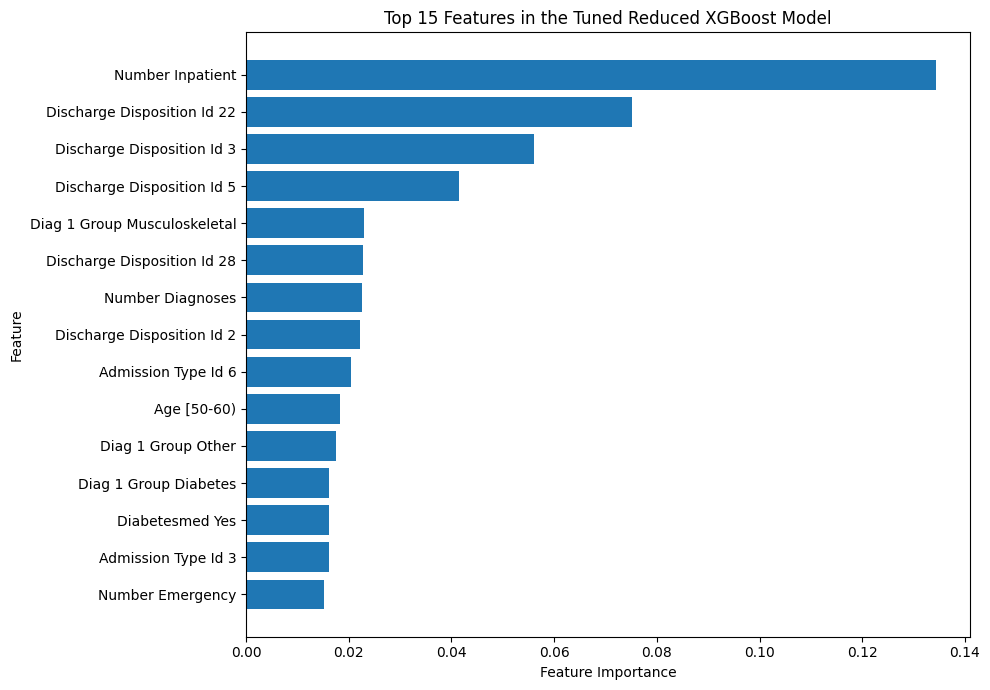

In [ ]:
top_features = (
    importance_df
    .head(15)
    .copy()
)

top_features["Feature"] = (
    top_features["Feature"]
    .str.replace(
        "num__",
        "",
        regex=False
    )
    .str.replace(
        "cat__",
        "",
        regex=False
    )
    .str.replace(
        "_",
        " ",
        regex=False
    )
    .str.title()
)

top_features = top_features.sort_values(
    "Importance"
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(
    "Top 15 Features in the Tuned Reduced XGBoost Model"
)

plt.tight_layout()
plt.show()


From the feature importance graph, we can see that inpatient visits were the most important feature in the final XGBoost model. There are also several discharge disposition categories that were highly important, which suggets that a patient’s discharge setting contributed to the model’s predictions. Diagnosis information, age, diabetes medication status, and previous emergency visits also contributed to readmission risk. These importance values do show us which features contributed the most to the model’s predictions, but they do not show whether a feature increases or decreases readmission risk. This means that they shouldn't be interpreted as causal.

# Final Model Recommendation

The base XGBoost model was chosen as the final model because it gave us the best overall balance between model performance and business value.

A threshold of 0.40 was chosen as the recommended default because it identified about 79% of the readmissions and had an estimated net value of about 3.40 million dollars. However, the best threshold really depends on the hospital's capacity. The dashboard I am creating will allow the threshold to be adjusted. This way one can see that the higher thresholds will provide a more resource-conscious option by flagging fewer patients.

Overall, this model is meant to help identify patients who may benefit from additional post-discharge support and should be used as a decision-support tool rather than replacing clinical judgment.


# Saving the Final Model




In [ ]:
import joblib

# Setting the recommended default threshold
recommended_threshold = 0.40

# Saving the final XGBoost pipeline
joblib.dump(
    xgb_pipeline,
    "readmission_xgboost_model.pkl"
)

# Saving the recommended default threshold
joblib.dump(
    recommended_threshold,
    "readmission_threshold.pkl"
)

print(
    "Model saved successfully."
)

print(
    "Default threshold saved successfully:",
    recommended_threshold
)

print(
    "Deployment inputs:",
    xgb_pipeline.feature_names_in_.tolist()
)

Model saved successfully.
Default threshold saved successfully: 0.4
Deployment inputs: ['age', 'admission_type_id', 'discharge_disposition_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'A1Cresult', 'diabetesMed', 'diag_1_group', 'diag_2_group', 'diag_3_group']
